# Hands-on exercise

In this simple example you are required to perform a simple linear regression with scipy. Find all the information on the function in the documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

### Assignment

1) Load the provided .csv file with the used car data

2) Use a linear regression to estimate the car prices from the year, kilometers or engine power. You can make a simple 1D regression from each one of the parameters independently (as an optional task you can also try a 2D or 3D regression combining multiple cues)

3) Firstly perform the estimation using the scipy linregress function (or alternatively you can use the sklearn.linear_model.LinearRegression class).
NB: check the documentation of the two methods!! In particular be aware of the number of outputs (in case use "_" to avoid the return of a specific output).

4) Have a look at the correlation coefficient to see which of the 3 features works better

5) Then implement the least square algorithm: you should get exactly the same solution of linregress !

6) Plot the data and the lines representing the output of the linregress and least square algorithms


In [28]:
import matplotlib.pyplot as plt
import csv
from scipy import stats
import numpy as np
import sklearn as sl
from sklearn import linear_model
import pandas as pd

Even though you imported the whole `sklearn` library with `import sklearn as sl`, this doesn't automatically make all the submodules available for direct use. Here's why:

1. **Namespace Management**: When you use `import sklearn as sl`, it only imports the top-level package, `sklearn`, under the alias `sl`. Submodules like `linear_model` are not immediately accessible—they remain within their own namespaces. In other words, `sl` contains only the reference to the main `sklearn` package, and you would have to explicitly reference submodules (like `sl.linear_model`) or import them separately.

2. **Efficiency**: Libraries like `scikit-learn` are large, and importing all submodules at once would unnecessarily increase memory usage and load time. By importing only what you need (e.g., `linear_model`), you make the program more efficient.

3. **Clarity and Explicitness**: Importing specific submodules, like `linear_model`, makes it clear which part of the library you are using in the code. This improves readability and helps avoid potential conflicts between submodules with the same name from different libraries.

### How the imports differ:
- `import sklearn as sl`: This imports the `sklearn` package under the alias `sl`, but you can only access modules within it by referencing them directly (e.g., `sl.linear_model`).
- `from sklearn import linear_model`: This imports the `linear_model` submodule directly, making its classes and functions accessible without prefixing them with `sl`.

### Example:

```python
import sklearn as sl

# This won't work because 'linear_model' has not been imported directly:
# model = linear_model.LinearRegression()  # Error

# But you can access it via 'sl':
model = sl.linear_model.LinearRegression()  # This works

# Alternatively, with the explicit import:
from sklearn import linear_model
model = linear_model.LinearRegression()  # This also works
```

In practice, importing only the submodules you need is a cleaner and more efficient approach.

In [3]:
# Load the provided data file with the used car data (you can also have a look at it with any text editor)

#file_datacars = "data/km_year_power_price.csv"
#infile = open(file_datacars,'r')
#lines loading --> qui ci sta la parte del ciclo for
#infile.close()  # remember to close the file when not used anymore --> must be done also at the end of the other method
#another way (simpler) to open the file 

filename = "data/km_year_power_price.csv"
lines = csv.reader(open(filename, newline=''), delimiter=',') #--> ogni elemento di lines è una lista di stringhe MA
# attenzione che csv.reader è un iteratore non un oggetto. Non ha dati dentro. Devo iterare e salvare le diverse righe in una lista

# place your loading code here 
car_km = []
car_year = []
car_powerPS = []
car_avgPrice = []

for i,line in enumerate(lines):
    if i == 0: 
        continue
    else: 
        car_km.append(float(line[0]))
        car_year.append(float(line[1]))
        car_powerPS.append(float(line[2]))
        car_avgPrice.append(float(line[3]))
car_km = np.asarray(car_km)

Quando diciamo che `csv.reader` è un "puntatore", ci riferiamo al fatto che agisce come un **iteratore** in Python. Un iteratore è un oggetto che permette di scorrere una sequenza di elementi uno alla volta, senza dover caricare tutti gli elementi in memoria contemporaneamente. In questo caso, `csv.reader` ti permette di iterare riga per riga attraverso il file CSV, piuttosto che caricare l'intero file in memoria.

### Cosa significa "puntatore" o iteratore?
In termini semplici:
- Quando esegui `csv.reader(open(filename))`, il file non viene caricato interamente in memoria.
- Invece, l'oggetto `csv.reader` funge da **puntatore** o iteratore che "punta" a una posizione nel file.
- Ogni volta che esegui un'operazione come un ciclo `for` o `next()`, l'iteratore legge e restituisce una riga del file alla volta, avanzando nel file fino alla fine.

### Esempio:
```python
import csv

# Apre il file CSV e crea un oggetto csv.reader
with open('file.csv', newline='') as f:
    reader = csv.reader(f)
    
    # Itera attraverso le righe del file CSV
    for row in reader:
        print(row)
```

In questo esempio, `reader` è un puntatore che legge il file `file.csv` una riga alla volta. La memoria viene utilizzata solo per la riga corrente, invece di caricare l'intero file, il che è particolarmente utile quando si lavora con file di grandi dimensioni.

### Vantaggi di essere un iteratore:
1. **Efficienza**: Non carica tutto in memoria, il che è utile per file molto grandi.
2. **Progressione**: Man mano che leggi il file, l'iteratore "avanza" da una riga alla successiva, gestendo la posizione nel file in modo trasparente.

In questo contesto, "puntatore" è una metafora per descrivere come l'oggetto `csv.reader` tenga traccia della posizione corrente nel file e avanzi una riga alla volta durante l'iterazione.

Use linear regression to estimate the car prices from the year, kilometers or engine power. 
You can make a simple 1D regression from each one of the parameters independently 




In [4]:
# linear regression with linregress (estimate price from year)

from scipy.stats import linregress

regression = linregress(car_year, car_avgPrice)

print(regression)

#I can also print only some of the returned values:
print(regression.slope, regression.intercept)


LinregressResult(slope=1509.093825335221, intercept=-3018309.484956958, rvalue=0.6767043169095441, pvalue=2.0722311599123473e-174, stderr=45.625811824073175, intercept_stderr=91628.09494333208)
1509.093825335221 -3018309.484956958


In [8]:
# (Optional) linear regression with linear_model.LinearRegression() (estimate price from year)
# Recall that in Python a mx1 matrix is different from a 1D array -> need to reshape

from sklearn.linear_model import LinearRegression

car_year = np.array(car_year)
car_avgPrice = np.array(car_avgPrice)

# Initialize the training_data array correctly
training_data = np.zeros((len(car_year), 2))
training_data[:, 0] = car_year
training_data[:, 1] = car_avgPrice

# Proceed with the regression model
model = LinearRegression()
model.fit(training_data[:, 0].reshape(-1, 1), training_data[:, 1])

# Predict the price for the year 2005
year_to_predict = np.array([[2005]])  # Reshape to 2D array
print(np.shape(year_to_predict))
predicted_price = model.predict(year_to_predict)

print(f"Predicted price for the year 2005: {predicted_price[0]}")


(1, 1)
Predicted price for the year 2005: 7423.634840160608


The line `model.fit(training_data[:, 0].reshape(-1, 1), training_data[:, 1])` is training (or "fitting") a linear regression model on your data. Here’s a detailed breakdown:

1. **`training_data[:, 0]`**: This selects the first column of `training_data`, which represents the `car_year` data (years of the cars). This is your independent variable (or feature) in the regression model.

2. **`.reshape(-1, 1)`**: This reshapes the `car_year` column into a 2D array with one column and as many rows as needed (specified by `-1`). The `reshape(-1, 1)` step is necessary because `fit()` expects the input data (`X`) to be in a 2D format, even if there’s only one feature. So if `training_data[:, 0]` has a shape of `(n,)`, `reshape(-1, 1)` converts it to `(n, 1)`.

3. **`training_data[:, 1]`**: This selects the second column of `training_data`, which represents the `car_avgPrice` data (average price of cars). This is your dependent variable (or target) in the regression model.

4. **`model.fit(X, y)`**: This function trains the linear regression model by finding the best-fit line that minimizes the squared error between the predicted values and the actual `car_avgPrice` values. Here:
   - `X = training_data[:, 0].reshape(-1, 1)` (input feature, `car_year`)
   - `y = training_data[:, 1]` (target variable, `car_avgPrice`)

After fitting, the `model` will contain coefficients (slope and intercept) that describe the best-fit line. You can use this trained model to make predictions on new data by calling `model.predict(new_data)` where `new_data` is a 2D array of years.

In `.reshape(-1, 1)`, the entries `-1` and `1` specify the shape of the array after reshaping:

1. **`-1`**: This is a placeholder that tells NumPy to automatically determine the number of rows based on the original data. Essentially, it lets NumPy figure out the appropriate row count to keep the total number of elements the same. For example, if your data has 10 elements, setting `-1` in `reshape` will make it choose 10 rows.

2. **`1`**: This specifies that the reshaped array should have exactly 1 column.

So, if `training_data[:, 0]` is a 1D array of shape `(n,)` (a single row with `n` elements), `reshape(-1, 1)` converts it into a 2D array with `n` rows and 1 column, giving it a shape of `(n, 1)`. This format is required by `scikit-learn`'s `fit()` method, which expects a 2D array for the feature matrix even if there is only one feature. 


In [6]:
# (Optional) perform linear regression with a manually implemented least squares (estimate price from year)
# You should get exactly the same solution of linregress !

# Step 1: Calculate the means of car_year and car_avgPrice
x_mean = np.mean(car_year)
y_mean = np.mean(car_avgPrice)

# Step 2: Calculate the slope (m)
numerator = np.sum((car_year - x_mean) * (car_avgPrice - y_mean))
denominator = np.sum((car_year - x_mean) ** 2)
m = numerator / denominator

# Step 3: Calculate the intercept (b)
b = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (b):", b)

# Step 4: Define the regression line function
def predict(year):
    return m * year + b

# Predict the price for a specific year
year_to_predict = 2005
predicted_price = predict(year_to_predict)
print(f"Predicted price for the year {year_to_predict}:", predicted_price)


Slope (m): 1509.0938253352201
Intercept (b): -3018309.484956956
Predicted price for the year 2005: 7423.634840160143


For a linear regression line \( y = m \cdot x + b \), the slope \( m \) and intercept \( b \) can be calculated as follows:

$$ m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} $$

$$ b = \bar{y} - m \cdot \bar{x} $$

where:
- \( x_i \) and \( y_i \) are individual data points (e.g., `car_year` and `car_avgPrice`).
- \( \bar{x} \) is the mean of the \( x \) values (mean year).
- \( \bar{y} \) is the mean of the \( y \) values (mean price).
 


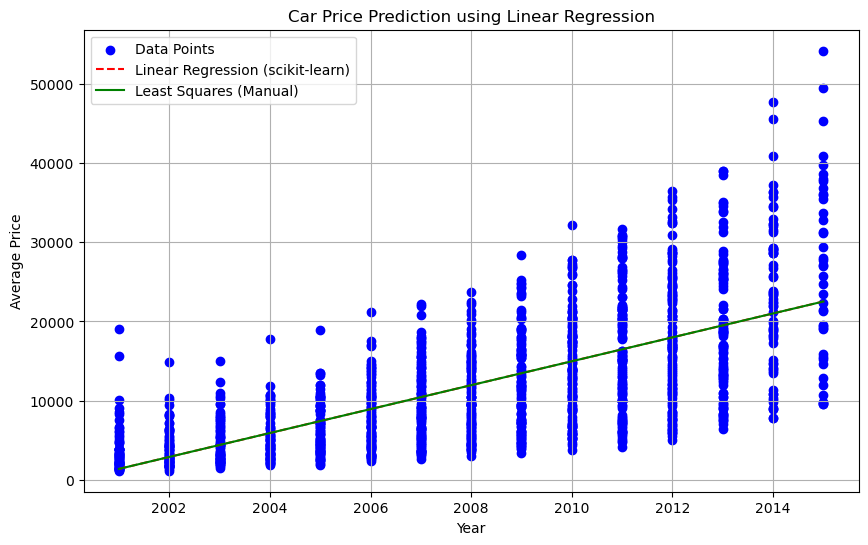

In [10]:
# Plot the data and the lines representing the output of the linregress and least square algorithms

#Generate predictions using both methods for plotting
years = np.linspace(min(car_year), max(car_year), 100)
sklearn_predictions = model.predict(years.reshape(-1, 1))
manual_predictions = m * years + b

plt.figure(figsize=(10, 6))
plt.scatter(car_year, car_avgPrice, color='blue', label='Data Points')  # Original data points
plt.plot(years, sklearn_predictions, color='red', linestyle='--', label='Linear Regression (scikit-learn)')
plt.plot(years, manual_predictions, color='green', linestyle='-', label='Least Squares (Manual)')

# Add labels and legend
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Car Price Prediction using Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

LinregressResult(slope=90.33080718820227, intercept=-1303.9126989879878, rvalue=0.7085500315263967, pvalue=2.6708763984333233e-198, stderr=2.4999213289302586, intercept_stderr=413.9119040279444)


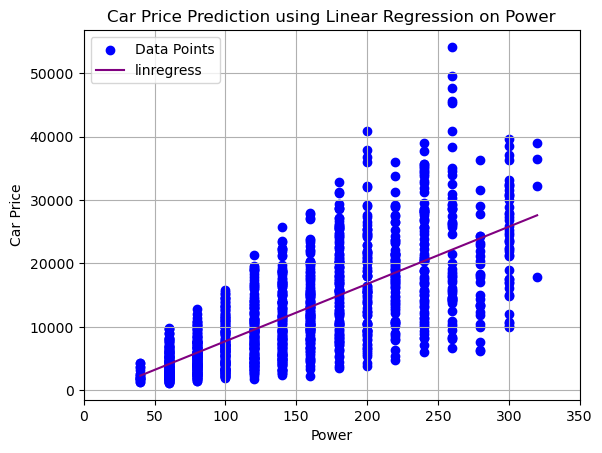

In [24]:
# linear regression with linregress (estimate price from power)
reg_power= linregress(car_powerPS, car_avgPrice)

print(reg_power)
slope_pp = reg_power.slope
intercept_pp = reg_power.intercept
power_range = np.linspace(min(car_powerPS), max(car_powerPS), 100)

predict_pp = slope_pp * power_range + intercept_pp

plt.scatter(car_powerPS, car_avgPrice, color='blue', label='Data Points')  # Original data points
plt.plot(power_range, predict_pp, color='purple', linestyle='-', label='linregress')

# Add labels and legend
plt.xlabel('Power')
plt.ylabel('Car Price')
plt.xlim(0,350)
plt.title('Car Price Prediction using Linear Regression on Power')
plt.legend()
plt.grid(True)
plt.show()


LinregressResult(slope=-0.054251513309725684, intercept=16692.34530251974, rvalue=-0.25728674299884985, pvalue=4.689714410723289e-21, stderr=0.005662227565052593, intercept_stderr=512.1908433023636)


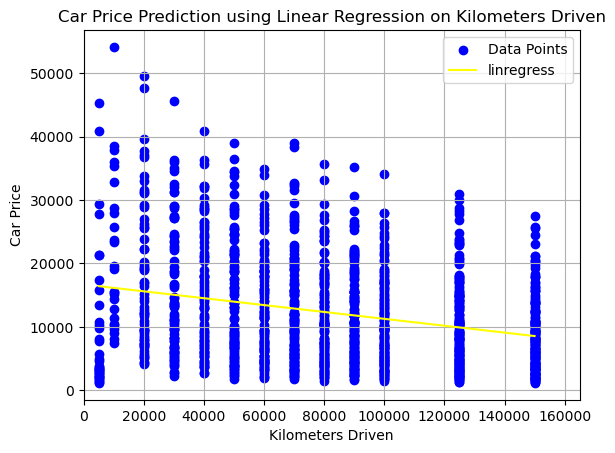

In [26]:
# linear regression with linregress (estimate price from km)

# Assume car_km and car_avgPrice are defined
reg_km = linregress(car_km, car_avgPrice)

print(reg_km)
slope_km = reg_km.slope
intercept_km = reg_km.intercept
km_range = np.linspace(min(car_km), max(car_km), 100)

predict_km = slope_km * km_range + intercept_km

plt.scatter(car_km, car_avgPrice, color='blue', label='Data Points')  # Original data points
plt.plot(km_range, predict_km, color='yellow', linestyle='-', label='linregress')

# Add labels and legend
plt.xlabel('Kilometers Driven')
plt.ylabel('Car Price')
plt.xlim(0, max(car_km) * 1.1)  # Adjust xlim for better visualization
plt.title('Car Price Prediction using Linear Regression on Kilometers Driven')
plt.legend()
plt.grid(True)
plt.show()


Correlation Coefficients with Car Price:
Year               0.676704
Power (PS)         0.708550
Kilometers (km)   -0.257287
Name: Price, dtype: float64


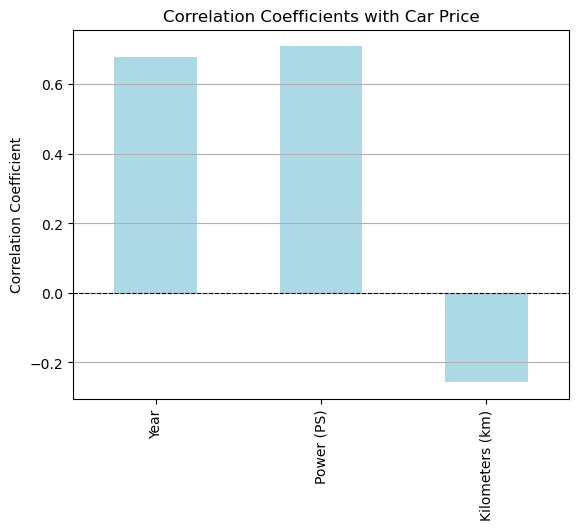

In [30]:
# Have a look at the correlation coefficients to see which of the 3 features works better

# Create a DataFrame to organize your data
data = pd.DataFrame({
    'Year': car_year,
    'Power (PS)': car_powerPS,
    'Kilometers (km)': car_km,
    'Price': car_avgPrice,
    # 'Age': car_age  # Uncomment if you have this feature
})

# Calculate correlation coefficients with respect to car price
correlations = data.corr()['Price'].drop('Price')  # Exclude the correlation of Price with itself

# Display the correlation coefficients
print("Correlation Coefficients with Car Price:")
print(correlations)

# Plotting correlation coefficients for better visualization
correlations.plot(kind='bar', color='lightblue')
plt.title('Correlation Coefficients with Car Price')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()


To evaluate which of the three features (for instance, power in PS, kilometers driven in km, and possibly another feature like car age) correlates most strongly with car prices, you can calculate the Pearson correlation coefficients for each feature with respect to car price. Below is a code snippet that demonstrates how to perform this analysis using Python:

### Steps Explained:
1. **Data Organization**: A pandas DataFrame is created to organize the features (power, kilometers, price, and age).
2. **Correlation Calculation**: The `corr()` method calculates the Pearson correlation coefficients, which measure the linear relationship between the features and car prices.
3. **Output and Visualization**: The correlation coefficients are printed and visualized in a bar chart for easy comparison.

### Interpretation of Correlation Coefficients:
- **Positive Correlation (0 to 1)**: Indicates that as the feature increases, the car price tends to increase.
- **Negative Correlation (-1 to 0)**: Indicates that as the feature increases, the car price tends to decrease.
- **Strength of Correlation**: Values closer to 1 or -1 indicate a stronger correlation, while values around 0 suggest weak or no correlation.

From this output, you can determine which feature has the strongest relationship with car price. The feature with the highest absolute value of the correlation coefficient is considered to have the strongest relationship.

Coefficients: Year = 1325.2284004046599, Power (PS) = 80.43004468885393, Intercept = -2661196.7867490603


C:\Users\giorg\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


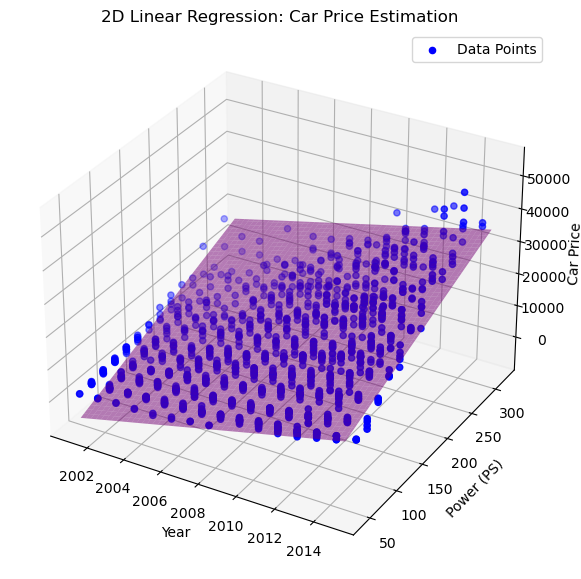

In [31]:
# (Optional) 2D linear regression with linear model (estimate price from year and power)

from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Prepare the features and target variable
X = data[['Year', 'Power (PS)']]  # Features
y = data['Price']  # Target variable

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficients and intercept
slope_year, slope_power = model.coef_
intercept = model.intercept_

print(f'Coefficients: Year = {slope_year}, Power (PS) = {slope_power}, Intercept = {intercept}')

# Create a meshgrid for plotting the regression surface
year_range = np.linspace(data['Year'].min(), data['Year'].max(), 100)
power_range = np.linspace(data['Power (PS)'].min(), data['Power (PS)'].max(), 100)
year_mesh, power_mesh = np.meshgrid(year_range, power_range)

# Predict prices based on the meshgrid
predicted_prices = model.predict(np.c_[year_mesh.ravel(), power_mesh.ravel()]).reshape(year_mesh.shape)

# 3D Plotting the regression surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points
ax.scatter(data['Year'], data['Power (PS)'], data['Price'], color='blue', label='Data Points')

# Plot the regression surface
ax.plot_surface(year_mesh, power_mesh, predicted_prices, color='purple', alpha=0.5)

# Set labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Power (PS)')
ax.set_zlabel('Car Price')
ax.set_title('2D Linear Regression: Car Price Estimation')

# Show the legend
ax.legend()

plt.show()


To perform a 2D linear regression using a linear model with two features (such as the year of the car and power in PS) to estimate car prices, you can use the `LinearRegression` class from `scikit-learn`.

### Steps Explained:
1. **Data Preparation**: A pandas DataFrame is created to store the car year, power in PS, and average price.
2. **Feature Selection**: The features (`Year` and `Power (PS)`) are separated from the target variable (`Price`).
3. **Model Fitting**: A linear regression model is created and fitted using `scikit-learn`.
4. **Coefficient Extraction**: The coefficients for the year and power, along with the intercept, are printed.
5. **Meshgrid Creation**: A meshgrid is created to facilitate surface plotting.
6. **Price Prediction**: The model predicts prices based on the meshgrid.
7. **3D Plotting**: The actual data points and the regression surface are plotted in a 3D space for visualization.

### Interpretation:
- The coefficients indicate how much the price changes with respect to changes in the year and power.
- The 3D plot helps visualize the relationship between the features and the estimated car prices, showing the trend of how prices change with varying years and power outputs.